# Build a frankenimage from F200W JWST image and an F814W image of the central region

This is just a santiy check that things are working with the F200W IFU constructed image. So we will use a similar filter in HST photometry and replace the image center with that.

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table


# Load and inspect the HST F814W image

In [2]:
hst_central = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/HST/MAST_2026-03-10T1856/HST/u2j20e07t/u2j20e07t_flt.fits")

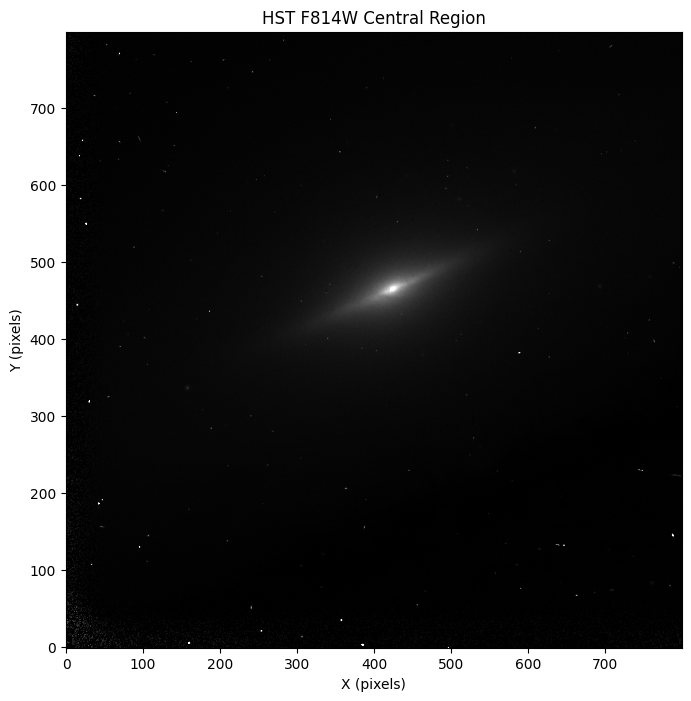

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(hst_central[1].data, origin="lower", cmap="gray",
            vmin=np.percentile(hst_central[1].data, 5), 
            vmax=np.percentile(hst_central[1].data, 99.99))
ax.set_title("HST F814W Central Region")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.show()

# Match the flux to the IFU image

In [4]:
# load the IFU image
ifu_image = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200_from_ifu_3.fits')

In [5]:
# do photometry in the inner 2 arcsec
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_area
from photutils.aperture import aperture_photometry, SkyCircularAperture
from astropy.coordinates import SkyCoord
import astropy.units as u

ra, dec = -170.00239509730588, -11.623046189498615 # central coordinates in degrees
positions = SkyCoord(ra, dec, unit='deg')
aperture = SkyCircularAperture(positions, r=0.6 * u.arcsec)

wcs_ifu = WCS(ifu_image[1].header)
wcs_hst = WCS(hst_central[1].header)

phot_ifu = aperture_photometry(ifu_image[1].data, aperture, wcs=wcs_ifu)
phot_hst = aperture_photometry(hst_central[1].data, aperture, wcs=wcs_hst)

Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


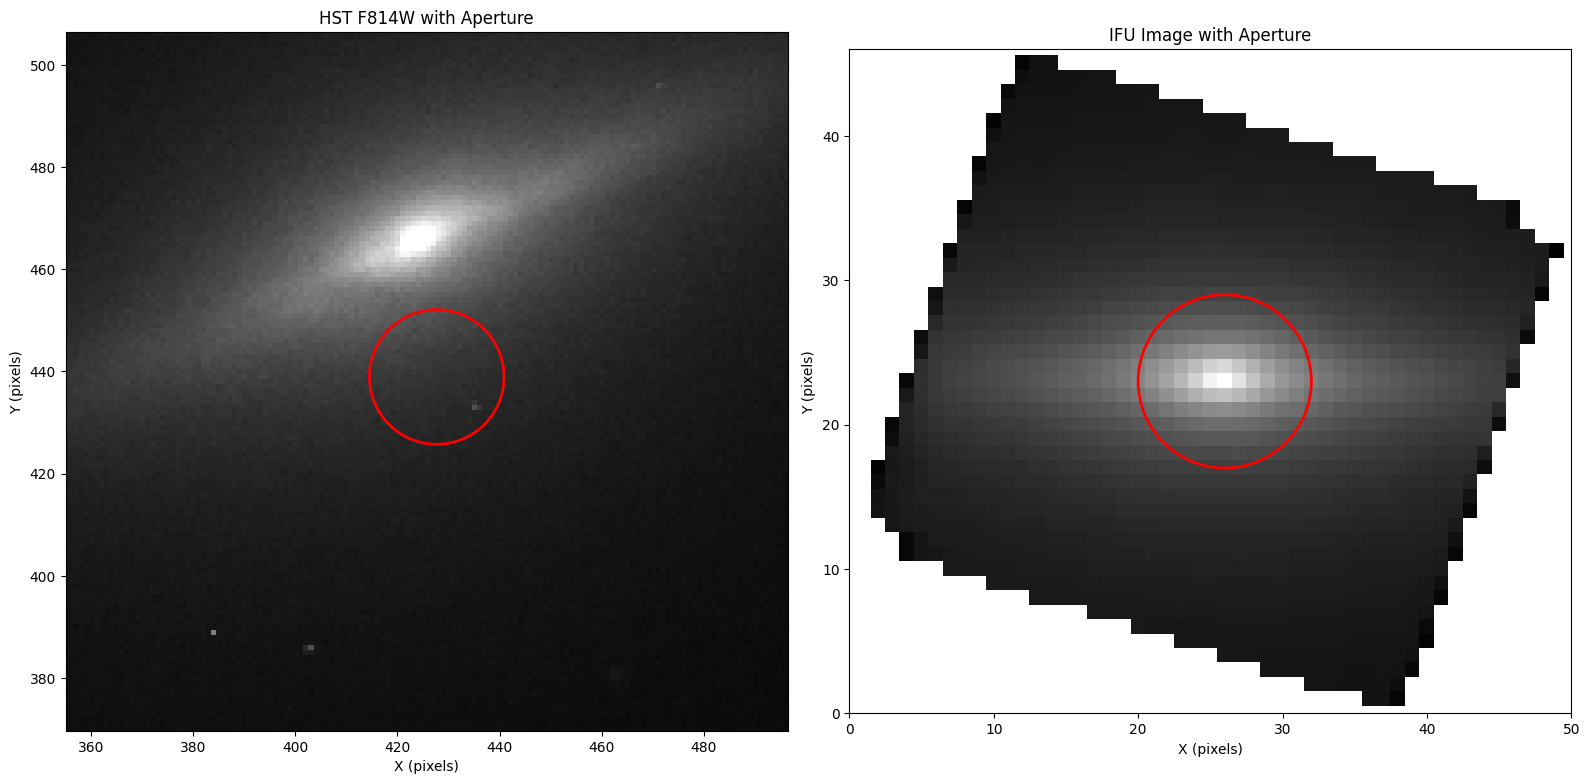

In [8]:
# utility for limits

def get_reference_footprint_skycoords(wcs_ref, nx, ny, nedge=100):
    """Sample the boundary of the reference image in pixel space,
    then convert to sky coordinates."""
    x_bottom = np.linspace(0, nx - 1, nedge)
    y_bottom = np.zeros(nedge)

    x_top = np.linspace(0, nx - 1, nedge)
    y_top = np.full(nedge, ny - 1)

    y_left = np.linspace(0, ny - 1, nedge)
    x_left = np.zeros(nedge)

    y_right = np.linspace(0, ny - 1, nedge)
    x_right = np.full(nedge, nx - 1)

    x = np.concatenate([x_bottom, x_top, x_left, x_right])
    y = np.concatenate([y_bottom, y_top, y_left, y_right])

    return wcs_ref.pixel_to_world(x, y)

ny_ref, nx_ref = ifu_image[1].data.shape
ref_sky = get_reference_footprint_skycoords(wcs_ifu, nx_ref, ny_ref)

def sky_limits_in_target_pixels(target_wcs, skycoords, shape):
    """Convert a sky footprint to pixel limits in a target WCS."""
    x, y = target_wcs.world_to_pixel(ref_sky)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    ny, nx = shape

    xlo = max(-0.5, np.nanmin(x))
    xhi = min(nx - 0.5, np.nanmax(x))
    ylo = max(-0.5, np.nanmin(y))
    yhi = min(ny - 0.5, np.nanmax(y))

    return xlo, xhi, ylo, yhi

lims_hst  = sky_limits_in_target_pixels(wcs_hst,  ref_sky, hst_central[1].data.shape)
lims_ifu  = sky_limits_in_target_pixels(wcs_ifu,  ref_sky, ifu_image[1].data.shape)

# plot the aperture on the HST image and the IFU image
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(hst_central[1].data, origin="lower", cmap="gray",
            vmin=np.percentile(hst_central[1].data, 5), 
            vmax=np.percentile(hst_central[1].data, 99.99))
ap_hst = aperture.to_pixel(wcs_hst)
ap_hst.plot(ax[0], color='red', lw=2)
ax[0].set_title("HST F814W with Aperture")
ax[0].set_xlabel("X (pixels)")
ax[0].set_ylabel("Y (pixels)")

ax[1].imshow(ifu_image[1].data, origin="lower", cmap="gray",
            vmin=np.nanmin(ifu_image[1].data), 
            vmax=np.nanmax(ifu_image[1].data))
ap_ifu = aperture.to_pixel(wcs_ifu)
ap_ifu.plot(ax[1], color='red', lw=2)
ax[1].set_title("IFU Image with Aperture")
ax[1].set_xlabel("X (pixels)")
ax[1].set_ylabel("Y (pixels)")

# set the axis limits
ax[0].set_xlim(lims_hst[0], lims_hst[1])
ax[0].set_ylim(lims_hst[2], lims_hst[3])
ax[1].set_xlim(lims_ifu[0], lims_ifu[1])
ax[1].set_ylim(lims_ifu[2], lims_ifu[3])
plt.tight_layout()
plt.show()

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_41256/920928026.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


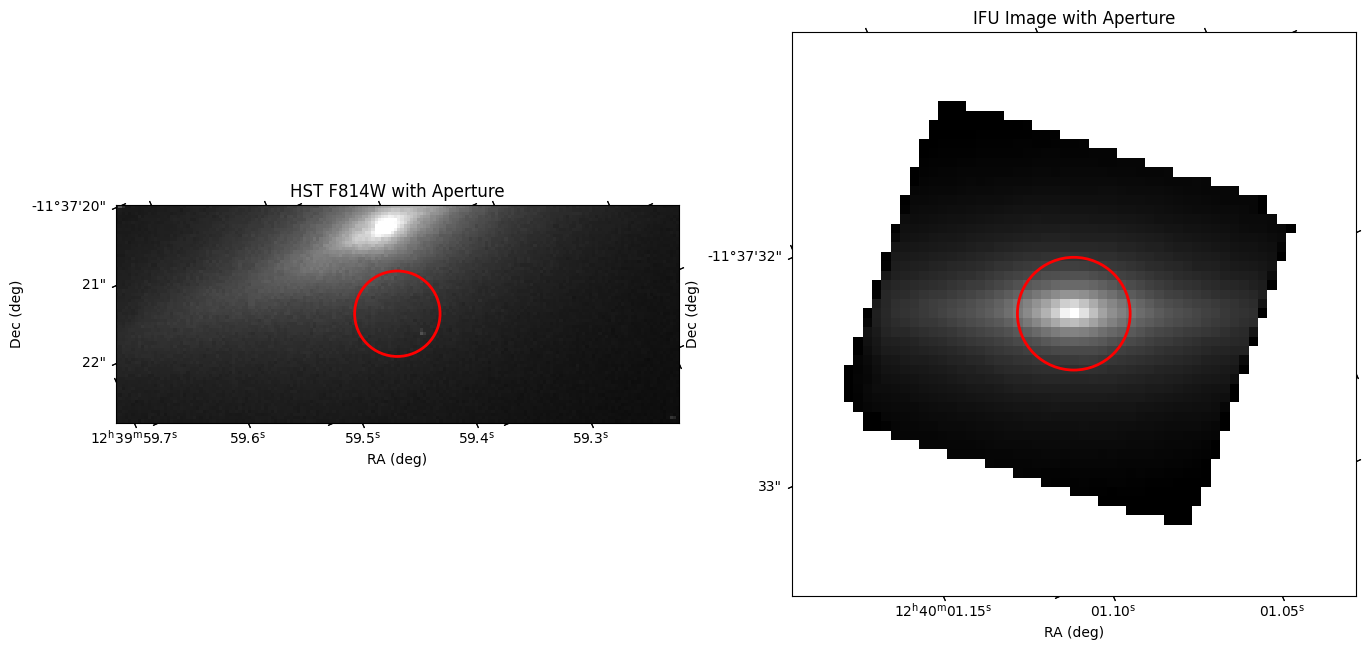

In [ ]:
# plot the aperture and image in sky coordinates using the HST WCS
fig, ax = plt.subplots(1,2, figsize=(16, 8), subplot_kw={'projection': wcs_hst})


ax[0].imshow(
     hst_central[1].data,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(hst_central[1].data, 5),
    vmax=np.nanpercentile(hst_central[1].data, 99.99)
)

# convert sky aperture to pixel aperture before plotting
ap_hst = aperture.to_pixel(wcs_hst)
ap_hst.plot(ax=ax[0], color='red', lw=2)

ax[0].set_title("HST F814W with Aperture")
ax[0].set_xlabel("RA (deg)")
ax[0].set_ylabel("Dec (deg)")

# For the IFU image, we need to convert the aperture to the IFU WCS
ap_ifu = aperture.to_pixel(wcs_ifu)
ap_ifu.plot(ax=ax[1], color='red', lw=2)
ax[1].imshow(
    ifu_image[1].data,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(ifu_image[1].data, 5),
    vmax=np.nanpercentile(ifu_image[1].data, 99.99)
)
ax[1].set_title("IFU Image with Aperture")
ax[1].set_xlabel("RA (deg)")
ax[1].set_ylabel("Dec (deg)")

# set the axis limits in sky coordinates 

pad = 3 * u.arcsec   # padding around the aperture center in sky coordinates

# aperture center in sky coords
center = aperture.positions   # assumes aperture is a sky aperture with one position

def set_limits_from_sky_padding(ax, wcs, center, pad):
    # define two opposite corners on the sky
    c1 = center.spherical_offsets_by(-pad, -pad)
    c2 = center.spherical_offsets_by(+pad, +pad)

    x1, y1 = wcs.world_to_pixel(c1)
    x2, y2 = wcs.world_to_pixel(c2)

    ax.set_xlim(min(x1, x2), max(x1, x2))
    ax.set_ylim(min(y1, y2), max(y1, y2))

set_limits_from_sky_padding(ax[0], wcs_hst, center, pad)
set_limits_from_sky_padding(ax[1], wcs_ifu, center, pad)
# ax[0].set_aspect('equal')
# ax[1].set_aspect('equal')
plt.tight_layout()
plt.show()

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_41256/814282605.py:59: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


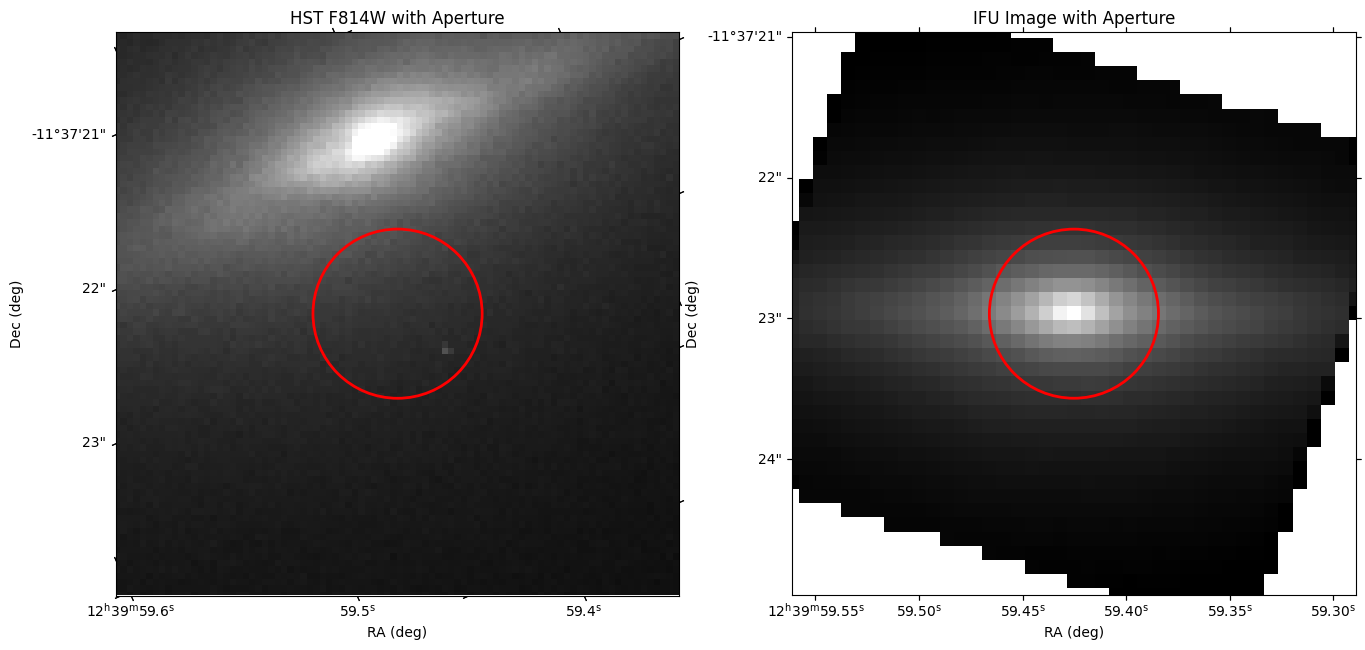

In [14]:
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 8))
ax0 = fig.add_subplot(1, 2, 1, projection=wcs_hst)
ax1 = fig.add_subplot(1, 2, 2, projection=wcs_ifu)

# --- HST ---
ax0.imshow(
    hst_central[1].data,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(hst_central[1].data, 5),
    vmax=np.nanpercentile(hst_central[1].data, 99.99)
)
ap_hst = aperture.to_pixel(wcs_hst)
ap_hst.plot(ax=ax0, color="red", lw=2)
ax0.set_title("HST F814W with Aperture")
ax0.set_xlabel("RA (deg)")
ax0.set_ylabel("Dec (deg)")

# --- IFU ---
ax1.imshow(
    ifu_image[1].data,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(ifu_image[1].data, 5),
    vmax=np.nanpercentile(ifu_image[1].data, 99.99)
)
ap_ifu = aperture.to_pixel(wcs_ifu)
ap_ifu.plot(ax=ax1, color="red", lw=2)
ax1.set_title("IFU Image with Aperture")
ax1.set_xlabel("RA (deg)")
ax1.set_ylabel("Dec (deg)")

def set_square_sky_limits(ax, wcs, center, half_size=5*u.arcsec):
    # center in pixels
    x0, y0 = wcs.celestial.world_to_pixel(center)

    # local projected pixel scales (deg / pix)
    sx, sy = proj_plane_pixel_scales(wcs.celestial) * u.deg

    # convert desired sky half-size into pixel half-sizes
    dx = (half_size.to(u.deg) / sx).value
    dy = (half_size.to(u.deg) / sy).value

    ax.set_xlim(x0 - dx, x0 + dx)
    ax.set_ylim(y0 - dy, y0 + dy)

    # make both subplot boxes look the same on the page
    ax.set_box_aspect(1)

center = aperture.positions
set_square_sky_limits(ax0, wcs_hst, center, half_size=2*u.arcsec)
set_square_sky_limits(ax1, wcs_ifu, center, half_size=2*u.arcsec)

plt.tight_layout()
plt.show()

# Align the two images

Original HST RA, Dec: 189.99773439783 -11.62320119078
Modified HST RA, Dec: 189.99773439783 -11.623562301891111


/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_41256/1560811068.py:62: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


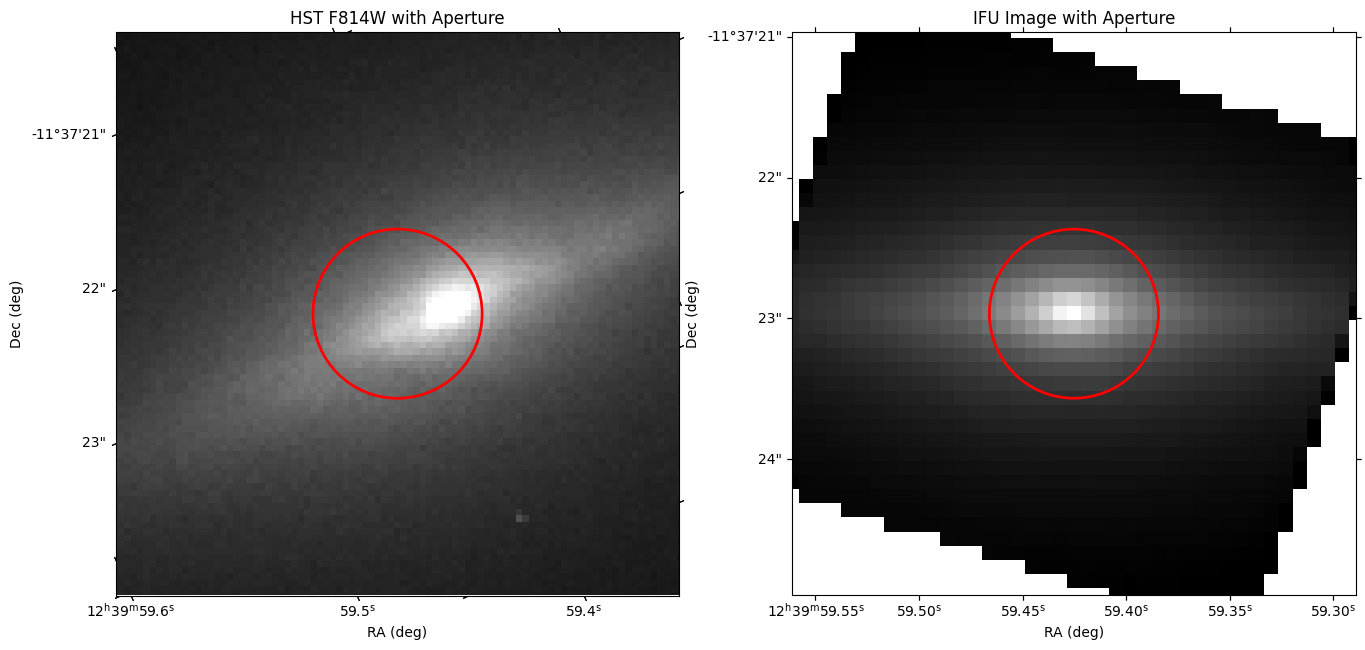

In [24]:
# move by hand the ra, dec in the hst header to match the ifu header
header_hst = hst_central[1].header.copy()
print("Original HST RA, Dec:", header_hst['CRVAL1'], header_hst['CRVAL2'])
# lets move dec by 1 arcsec
header_hst['CRVAL2'] -= 1.3/3600  # 1 arcsec in degrees
print("Modified HST RA, Dec:", header_hst['CRVAL1'], header_hst['CRVAL2'])

wcs_hst_mod = WCS(header_hst)
fig = plt.figure(figsize=(16, 8))
ax0 = fig.add_subplot(1, 2, 1, projection=wcs_hst_mod)
ax1 = fig.add_subplot(1, 2, 2, projection=wcs_ifu)

# --- HST ---
ax0.imshow(
    hst_central[1].data,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(hst_central[1].data, 5),
    vmax=np.nanpercentile(hst_central[1].data, 99.99)
)
ap_hst = aperture.to_pixel(wcs_hst_mod)
ap_hst.plot(ax=ax0, color="red", lw=2)
ax0.set_title("HST F814W with Aperture")
ax0.set_xlabel("RA (deg)")
ax0.set_ylabel("Dec (deg)")

# --- IFU ---
ax1.imshow(
    ifu_image[1].data,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(ifu_image[1].data, 5),
    vmax=np.nanpercentile(ifu_image[1].data, 99.99)
)
ap_ifu = aperture.to_pixel(wcs_ifu)
ap_ifu.plot(ax=ax1, color="red", lw=2)
ax1.set_title("IFU Image with Aperture")
ax1.set_xlabel("RA (deg)")
ax1.set_ylabel("Dec (deg)")

def set_square_sky_limits(ax, wcs, center, half_size=5*u.arcsec):
    # center in pixels
    x0, y0 = wcs.celestial.world_to_pixel(center)

    # local projected pixel scales (deg / pix)
    sx, sy = proj_plane_pixel_scales(wcs.celestial) * u.deg

    # convert desired sky half-size into pixel half-sizes
    dx = (half_size.to(u.deg) / sx).value
    dy = (half_size.to(u.deg) / sy).value

    ax.set_xlim(x0 - dx, x0 + dx)
    ax.set_ylim(y0 - dy, y0 + dy)

    # make both subplot boxes look the same on the page
    ax.set_box_aspect(1)

center = aperture.positions
set_square_sky_limits(ax0, wcs_hst_mod, center, half_size=2*u.arcsec)
set_square_sky_limits(ax1, wcs_ifu, center, half_size=2*u.arcsec)

plt.tight_layout()
plt.show()


In [26]:
# find maximum pixel value in the HST image and the IFU image
# find the maximum pixel in the ifu image for the photometry
max_y, max_x = np.unravel_index(np.nanargmax(ifu_image[1].data), ifu_image[1].data.shape)
print(f"Maximum pixel in IFU image: (X={max_x}, Y={max_y})")

ra, dec = wcs_ifu.wcs_pix2world(max_x, max_y, 0)
print(f"Maximum pixel in IFU image corresponds to RA={ra}, Dec={dec}")

Maximum pixel in IFU image: (X=26, Y=23)
Maximum pixel in IFU image corresponds to RA=-170.00239509730588, Dec=-11.623046189498615


In [28]:
# find the maximum pixel in the hst image for the photometry
max_y_hst, max_x_hst = np.unravel_index(np.nanargmax(hst_central[1].data), hst_central[1].data.shape)
print(f"Maximum pixel in HST image: (X={max_x_hst}, Y={max_y_hst})")
ra_hst, dec_hst = wcs_hst.wcs_pix2world(max_x_hst, max_y_hst, 0)
print(f"Maximum pixel in HST image corresponds to RA={ra_hst}, Dec={dec_hst}")

Maximum pixel in HST image: (X=385, Y=4)
Maximum pixel in HST image corresponds to RA=190.00039716903433, Dec=-11.627859283296777
